# EJERCICIO 1 
# Curvas ROC y AUC en Python

In [ ]:
from sklearn.datasets import make_classification 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

In [11]:
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

In [13]:
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.5, random_state=2)

In [15]:
ns_probs = [0 for _ in range(len(testy))]

In [17]:
model = LogisticRegression(solver='lbfgs')
model.fit(trainX, trainy)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
lr_probs = model.predict_proba(testX)
lr_probs = lr_probs[:, 1]

In [21]:
ns_auc = roc_auc_score(testy, ns_probs)
lr_auc = roc_auc_score(testy, lr_probs)

In [23]:
print('Sin entrenar: ROC AUC=%.3f' % (ns_auc))
print('Regresión Logística: ROC AUC=%.3f' % (lr_auc))

Sin entrenar: ROC AUC=0.500
Regresión Logística: ROC AUC=0.903


In [25]:
ns_fpr, ns_tpr, _ = roc_curve(testy, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(testy, lr_probs)

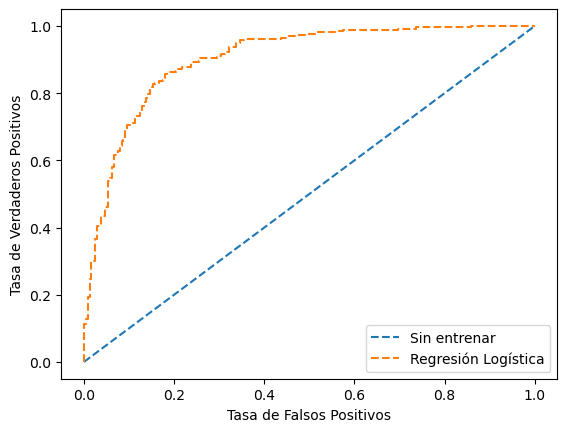

In [27]:
pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='Sin entrenar')
pyplot.plot(lr_fpr, lr_tpr, linestyle='--', label='Regresión Logística')
pyplot.xlabel('Tasa de Falsos Positivos')
pyplot.ylabel('Tasa de Verdaderos Positivos')
pyplot.legend()
pyplot.show()

# Ejercicio 2
# Explorando la Regresión Logística con Regularización

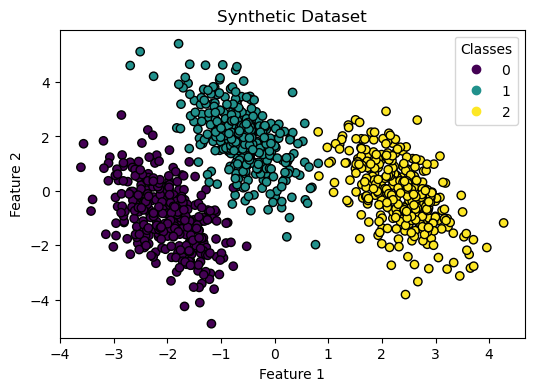

In [33]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_blobs

centers = [[-5, 0], [0, 1.5], [5, -1]]
X, y = make_blobs(n_samples=1_000, centers=centers, random_state=40)
transformation = [[0.4, 0.2], [-0.4, 1.2]]
X = np.dot(X, transformation)

fig, ax = plt.subplots(figsize=(6, 4))

scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="black")
ax.set(title="Synthetic Dataset", xlabel="Feature 1", ylabel="Feature 2")
_ = ax.legend(*scatter.legend_elements(), title="Classes")

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

logistic_regression_multinomial = LogisticRegression().fit(X, y)
logistic_regression_ovr = OneVsRestClassifier(LogisticRegression()).fit(X, y)

accuracy_multinomial = logistic_regression_multinomial.score(X, y)
accuracy_ovr = logistic_regression_ovr.score(X, y)

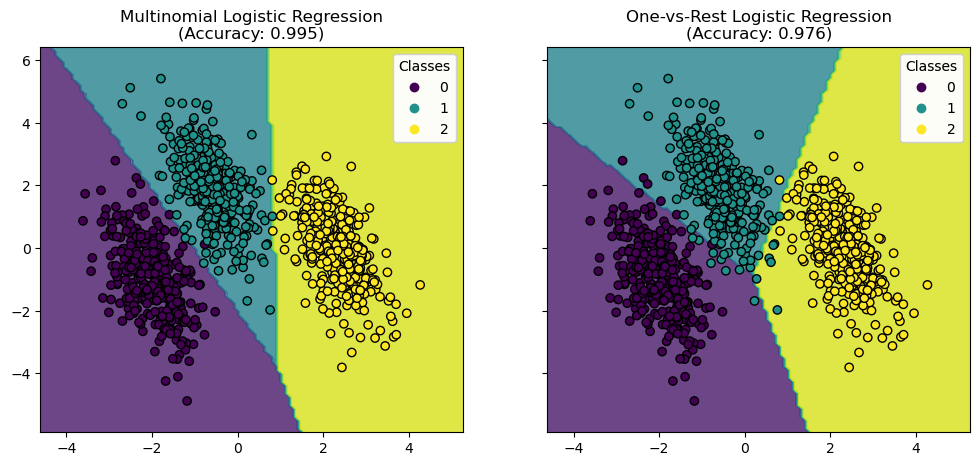

In [37]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for model, title, ax in [
    (
        logistic_regression_multinomial,
        f"Multinomial Logistic Regression\n(Accuracy: {accuracy_multinomial:.3f})",
        ax1,
    ),
    (
        logistic_regression_ovr,
        f"One-vs-Rest Logistic Regression\n(Accuracy: {accuracy_ovr:.3f})",
        ax2,
    ),
]:
    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        ax=ax,
        response_method="predict",
        alpha=0.8,
    )
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    legend = ax.legend(*scatter.legend_elements(), title="Classes")
    ax.add_artist(legend)
    ax.set_title(title)

In [39]:
def plot_hyperplanes(classifier, X, ax):
    xmin, xmax = X[:, 0].min(), X[:, 0].max()
    ymin, ymax = X[:, 1].min(), X[:, 1].max()
    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax))

    if isinstance(classifier, OneVsRestClassifier):
        coef = np.concatenate([est.coef_ for est in classifier.estimators_])
        intercept = np.concatenate([est.intercept_ for est in classifier.estimators_])
    else:
        coef = classifier.coef_
        intercept = classifier.intercept_

    for i in range(coef.shape[0]):
        w = coef[i]
        a = -w[0] / w[1]
        xx = np.linspace(xmin, xmax)
        yy = a * xx - (intercept[i]) / w[1]
        ax.plot(xx, yy, "--", linewidth=3, label=f"Class {i}")

    return ax.get_legend_handles_labels()

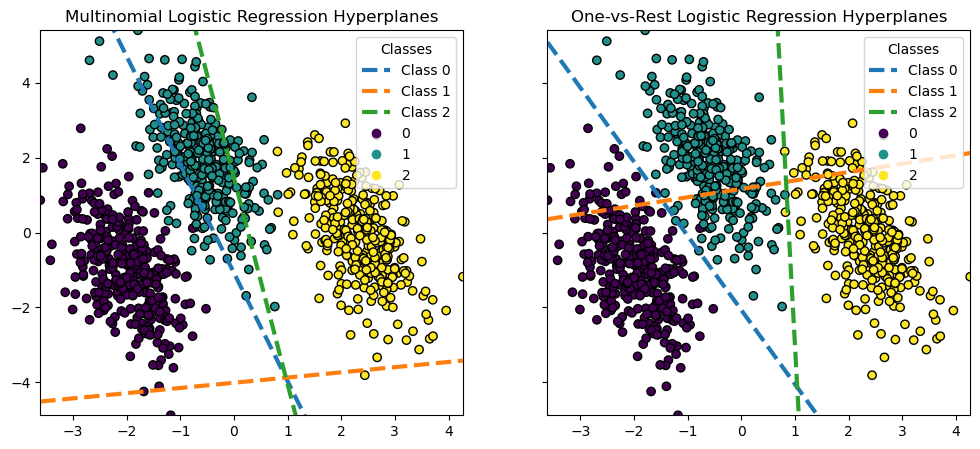

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for model, title, ax in [
    (
        logistic_regression_multinomial,
        "Multinomial Logistic Regression Hyperplanes",
        ax1,
    ),
    (logistic_regression_ovr, "One-vs-Rest Logistic Regression Hyperplanes", ax2),
]:
    hyperplane_handles, hyperplane_labels = plot_hyperplanes(model, X, ax)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    scatter_handles, scatter_labels = scatter.legend_elements()

    all_handles = hyperplane_handles + scatter_handles
    all_labels = hyperplane_labels + scatter_labels

    ax.legend(all_handles, all_labels, title="Classes")
    ax.set_title(title)

plt.show()

¿Qué diferencias observas en las fronteras de decisión entre los dos enfoques?

En la gráfica, la regresión logística multinomial crea regiones más “ordenadas” y coherentes entre las tres clases, con límites que encajan mejor entre sí (por ejemplo, la separación hacia la derecha para la clase amarilla se ve más estable). En cambio, One-vs-Rest muestra fronteras menos consistentes porque cada clase se entrena contra “el resto”, y eso hace que algunas zonas queden con cortes raros o transiciones menos limpias, sobre todo alrededor de la clase del centro.


¿Cómo afectan las fronteras de decisión al rendimiento del modelo?

Las fronteras afectan directamente cuántos puntos quedan del lado correcto: cuando los límites separan bien las nubes, el modelo se equivoca poco. Por eso el multinomial tiene mayor accuracy (0.995), ya que sus fronteras se ajustan mejor a la separación global de las tres clases, mientras que OvR (0.976) deja más puntos cerca de regiones equivocadas, especialmente donde hay mezcla entre clases.


¿Qué ventajas tiene la regresión logística multinomial sobre la regresión One-vs-Rest?

La multinomial tiene la ventaja de que aprende las tres clases al mismo tiempo con una sola optimización (softmax), así que “compara” las clases entre sí de manera directa y mantiene fronteras más coherentes. En OvR se entrenan varios modelos binarios independientes, y como cada uno define el “resto” de forma distinta, pueden aparecer conflictos entre hiperplanos que terminan afectando la decisión final.


¿Cómo podrías mejorar las fronteras de decisión para una mejor clasificación?

Podría mejorar las fronteras ajustando la regularización (parámetro C) y escalando las variables para que el modelo encuentre límites más adecuados y estables. Si el problema real necesitara separaciones curvas, también se puede mejorar usando características polinomiales con regresión logística o cambiando a modelos no lineales como SVM con kernel, para capturar mejor la forma de las nubes sin depender solo de líneas rectas.


¿Qué impacto tienen las fronteras de decisión en la capacidad del modelo para generalizar?

Las fronteras determinan qué tan bien el modelo clasifica datos nuevos: si el límite está bien colocado y no es “caprichoso”, generaliza mejor. Cuando las fronteras quedan inconsistentes o demasiado sensibles a ciertas zonas (como puede pasar en OvR), aumenta el riesgo de fallar con puntos nuevos cerca de los bordes; y si las fronteras fueran demasiado complejas, también podría haber sobreajuste, por eso conviene validar con train/test split o cross-validation.

# EJERCICIO 3 
# Implementar y corregir los errores de binary_classification_rice.ipynb